In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import os
import seaborn as sb
from statistics import mean
style.use('fast')
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score  
from statistics import mean

def ROC_PR_AUC_Curves(Values_real,Value_infered, number_genes, file_path_data, algorithm, color_ROC="indigo", color_PR= "springgreen", show_plot=False):
    """
        This functions returns the area under the ROC and PR curve 
        and plots the tpr vs fpr and the precision vs recall.
    """
    
    #ROC
    fpr, tpr, thresholds = roc_curve(Values_real, Value_infered)
    AUC_ROC = auc(fpr, tpr)
    
    
    #PR
    precision, recall, thresholds = precision_recall_curve(Values_real, Value_infered)
    AUC_PR = auc(recall, precision)
    
    if show_plot==True:
        
        print("No plot")
    
    return AUC_ROC, AUC_PR


In [12]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
Nodes = [10,20,50,100]
In_degree = [2]
         
Algorithm = ["SWING", "dynGENIE3"]
mean_importance = {}

for nodes in Nodes:
   
    for degree in In_degree:
            
        for algorithm in Algorithm:
            
            mean_importance[f"{algorithm}_{nodes}Nodes"] = pd.DataFrame()
            mean_importance[f"{algorithm}_{nodes}Nodes_rand"] = pd.DataFrame()
            
            for instance in range(100):
        
                instance = instance + 1
            
                if algorithm == "SWING":    
                                                            
                    mean_importance_file_SWING = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t").sort_values(by=["regulator-target"])
                    mean_importance_file_SWING_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t").sort_values(by=["regulator-target"])
                    
                    mean_importance[f"{algorithm}_{nodes}Nodes"][f"instance_{instance}"] = mean_importance_file_SWING["mean_importance"].values.tolist()
                    mean_importance[f"{algorithm}_{nodes}Nodes_rand"][f"instance_{instance}_rand"] = mean_importance_file_SWING_rand["mean_importance"].values.tolist()
                    
                else:
                    
                    mean_importance_file_dynGENIE3= pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])
                    mean_importance_file_dynGENIE3_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])
                    
                    mean_importance[f"{algorithm}_{nodes}Nodes"][f"instance_{instance}"] = mean_importance_file_dynGENIE3["mean_importance"].values.tolist()
                    mean_importance[f"{algorithm}_{nodes}Nodes_rand"][f"instance_{instance}"] = mean_importance_file_dynGENIE3_rand["mean_importance"].values.tolist()
                    

## Testing linear combination on the ranked lists

$Ins_{i} = Ins_{i} + \alpha (Ins_{i} - Is_{i})$

In [53]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
Nodes = [50] #[10,20,50,100]
Alpha = np.arange(0,10,0.8)
In_degree = [2]
         
Algorithm = ["SWING", "dynGENIE3"]
mean_importance = {}
AUROC = {}
AUPRC = {}
    
for nodes in Nodes:
    print(nodes)
    for degree in In_degree:
                
        for algorithm in Algorithm:
            
            for alpha in Alpha:
                
                AUROC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"] = []
                AUPRC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"] = []
                
                for instance in range(100):
            
                    instance = instance + 1
                    
                    gold_standard = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Networks_in_out_degree_{degree}_num_nodes_{nodes}/in_and_out_degree_{degree}_num_nodes_{nodes}_case_{instance}/goldstandard_signed_{instance}_goldstandard.tsv", sep="\t", names= header_list)
                    gold_standard = gold_standard.sort_values(by=["Cause Gene", "Effect Gene"])
                    

                    if algorithm == "SWING":    
                                                                
                        mean_importance_file = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t").sort_values(by=["regulator-target"])
                        mean_importance_file_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t").sort_values(by=["regulator-target"])
                         
                    else:
                        
                        mean_importance_file = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])
                        mean_importance_file_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])
                    
                    for i in range(len(mean_importance_file["mean_importance"])):
                            mean_importance_file["mean_importance"].iloc[i] = mean_importance_file["mean_importance"].iloc[i] + alpha*(mean_importance_file["mean_importance"].iloc[i] - mean_importance_file_rand["mean_importance"].iloc[i])
                       
                        
                    AUROC_value, AUPRC_value = ROC_PR_AUC_Curves(gold_standard["mean_importance"], mean_importance_file["mean_importance"] , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
                    
                    AUROC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"].append(AUROC_value)
                    AUPRC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"].append(AUPRC_value)

50


C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

...

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
C:\Users\ivana\anaconda3\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

## Overall score vs alpha

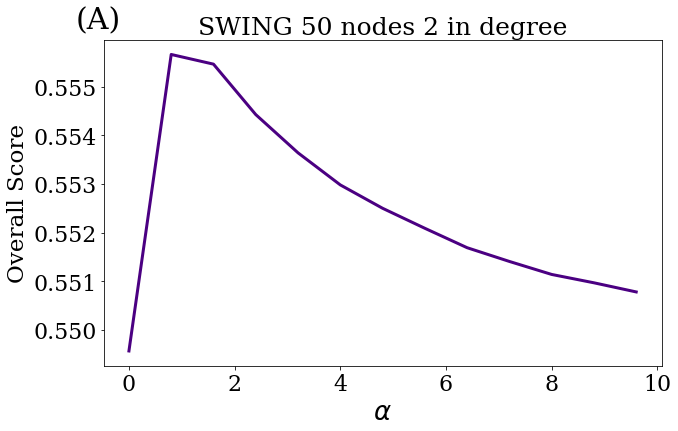

In [89]:
plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
algorithm = "SWING"
degree = 2

nodes = 50
plt.figure(figsize=(10,6))
overallscore = [np.power(np.prod(AUROC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"]),1/100)/2 + np.power(np.prod(AUPRC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"]),1/100)/2 for alpha in Alpha]
overallscore_file = open("C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Alpha_SWING_50genes_2degree.txt", "w")
for element in overallscore:
    overallscore_file.write(str(element) + "\n")
overallscore_file.close()
plt.plot(Alpha, overallscore, '-', color = "indigo", lw = 3)
plt.xlabel(r'${\alpha}$', fontsize = 26, family = "serif")
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} nodes 2 in degree", fontsize = 25)
plt.text(-1,0.5562, "(A)", fontsize = 30)
plt.savefig("C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Alpha_SWING_50genes_2degree.png", bbox_inches = "tight", dpi= 100)

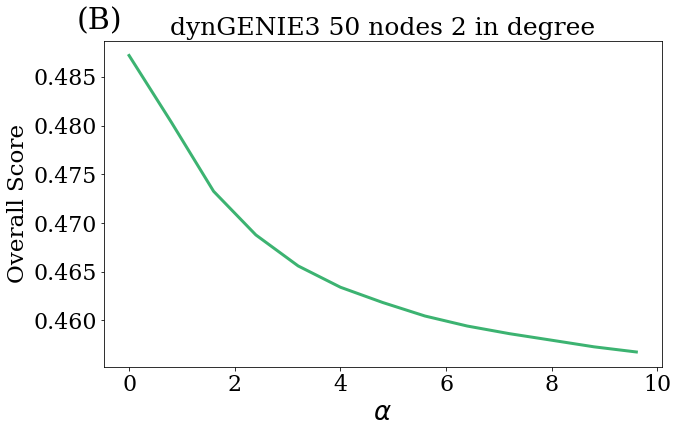

In [90]:
plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
algorithm = "dynGENIE3"
degree = 2

nodes = 50
plt.figure(figsize=(10,6))
overallscore = [np.power(np.prod(AUROC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"]),1/100)/2 + np.power(np.prod(AUPRC[f"{algorithm}_{nodes}Nodes_{alpha}alpha"]),1/100)/2 for alpha in Alpha]
overallscore_file = open("C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Alpha_dynGENIE3_50genes_2degree.txt", "w")
for element in overallscore:
    overallscore_file.write(str(element) + "\n")
overallscore_file.close()
plt.plot(Alpha, overallscore, '-', color = "mediumseagreen", lw = 3)
plt.xlabel(r'$\alpha$', fontsize = 26)
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} nodes 2 in degree", fontsize = 25)
plt.text(-1,0.4899, "(B)", fontsize = 30)
plt.savefig("C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Alpha_dynGENIE3_50genes_2degree.png", bbox_inches = "tight", dpi= 100)